# Определение стоимости автомобилей

Сервис по продаже автомобилей с пробегом «Не бит, не крашен» разрабатывает приложение для привлечения новых клиентов. В нём можно быстро узнать рыночную стоимость своего автомобиля. В вашем распоряжении исторические данные: технические характеристики, комплектации и цены автомобилей. Вам нужно построить модель для определения стоимости. 

Заказчику важны:

- качество предсказания;
- скорость предсказания;
- время обучения.

**Импортируем и установим все необходимые библиотеки для исследования:**

(некоторые библиотеки могут установиться не с первого раза)

In [1]:
#!pip install numpy==1.26.4 

In [2]:
#!pip install matplotlib==3.5.0

In [3]:
#!pip install phik

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import sklearn
import phik
import time
import lightgbm as lgb
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.metrics import mean_squared_error
RANDOM_STATE = 42
TEST_SIZE = 0.2
VAL_SIZE = 0.25

## Подготовка данных

### Загрузка данных

Считаем CSV-файл с данными с помощью библиотеки pandas и сохраним в датафрейм.

In [5]:
autos = pd.read_csv('/datasets/autos.csv')

Выведем первые строки датафрейма, чтобы проверить, правильно ли считались данные:

In [6]:
autos.head()

,DateCrawled,Price,VehicleType,RegistrationYear,Gearbox,Power,Model,Kilometer,RegistrationMonth,FuelType,Brand,Repaired,DateCreated,NumberOfPictures,PostalCode,LastSeen
0,2016-03-24 11:52:17,480,NaN,1993,manual,0,golf,150000,0,petrol,volkswagen,NaN,2016-03-24 00:00:00,0,70435,2016-04-07 03:16:57
1,2016-03-24 10:58:45,18300,coupe,2011,manual,190,NaN,125000,5,gasoline,audi,yes,2016-03-24 00:00:00,0,66954,2016-04-07 01:46:50
2,2016-03-14 12:52:21,9800,suv,2004,auto,163,grand,125000,8,gasoline,jeep,NaN,2016-03-14 00:00:00,0,90480,2016-04-05 12:47:46
3,2016-03-17 16:54:04,1500,small,2001,manual,75,golf,150000,6,petrol,volkswagen,no,2016-03-17 00:00:00,0,91074,2016-03-17 17:40:17
4,2016-03-31 17:25:20,3600,small,2008,manual,69,fabia,90000,7,gasoline,skoda,no,2016-03-31 00:00:00,0,60437,2016-04-06 10:17:21


Можно говорить о том, что CSV-файл считался правильно, и с ним можно работать.

### Предобработка данных

Изучим данные и сделаем выводы. 

#### Изучим общую информацию о датафреймах

Теперь для лучшего понимания данных, хранящихся в датафрейме, выведем информацию о нем методом `.info()`:

In [7]:
autos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 354369 entries, 0 to 354368
Data columns (total 16 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   DateCrawled        354369 non-null  object
 1   Price              354369 non-null  int64 
 2   VehicleType        316879 non-null  object
 3   RegistrationYear   354369 non-null  int64 
 4   Gearbox            334536 non-null  object
 5   Power              354369 non-null  int64 
 6   Model              334664 non-null  object
 7   Kilometer          354369 non-null  int64 
 8   RegistrationMonth  354369 non-null  int64 
 9   FuelType           321474 non-null  object
 10  Brand              354369 non-null  object
 11  Repaired           283215 non-null  object
 12  DateCreated        354369 non-null  object
 13  NumberOfPictures   354369 non-null  int64 
 14  PostalCode         354369 non-null  int64 
 15  LastSeen           354369 non-null  object
dtypes: int64(7), object(

Выведем размеры датафрейма:

In [8]:
autos.shape

(354369, 16)

Из общей информации по датафрему можно говорить о том, что данные в столбцах и их тип соответствуют действительности, и изменять ничего не нужно.

Из полученной информации видно, что необходимо привести названия столбцов датафрейма к общепринятому виду - прописные буквы, "змеевидная" запись(через нижнее подчеркивание), латинский алфавит.

Приведём названия столбцов датафрейма к нижнему регистру:

In [9]:
autos.columns = autos.columns.str.lower()

Теперь преобразуем к змеевидной записи столбцы, которые имеют "сложное" название - то есть два и более слов, к примеру `'registrationmonth'` к виду `'registration_month'` или `'numberofpictures'` к виду `'number_of_pictures'`:

In [10]:
autos = autos.rename(columns={  'datecrawled':'date_crawled', 
                                'vehicletype':'vehicle_type', 
                                'registrationyear':'registration_year', 
                                'registrationmonth':'registration_month', 
                                'fueltype':'fuel_type', 
                                'notrepaired':'not_repaired', 
                                'datecreated':'date_created',
                                'numberofpictures': 'number_of_pictures',
                                'postalcode':'postal_code',
                                'lastseen':'last_seen'})

Проверим преобразование названий:

In [11]:
autos.columns

Index(['date_crawled', 'price', 'vehicle_type', 'registration_year', 'gearbox',
       'power', 'model', 'kilometer', 'registration_month', 'fuel_type',
       'brand', 'repaired', 'date_created', 'number_of_pictures',
       'postal_code', 'last_seen'],
      dtype='object')

Изменения были успешно проделаны.

#### Проверим наличие пропусков в данных

Из вывода общей информации заметно, что есть пропуски в данных.

Воспользуемся методом `.isna()` для поиска пропусков во всех датафреймах и просуммируем их методом `.sum()`:

In [12]:
autos.isna().sum()

date_crawled              0
price                     0
vehicle_type          37490
registration_year         0
gearbox               19833
power                     0
model                 19705
kilometer                 0
registration_month        0
fuel_type             32895
brand                     0
repaired              71154
date_created              0
number_of_pictures        0
postal_code               0
last_seen                 0
dtype: int64

In [13]:
print('Процентное соотношение количества пропусков к общему числу данных:\n', round((autos.isna().sum() * 100) / len(autos),3))

Процентное соотношение количества пропусков к общему числу данных:
 date_crawled           0.000
price                  0.000
vehicle_type          10.579
registration_year      0.000
gearbox                5.597
power                  0.000
model                  5.561
kilometer              0.000
registration_month     0.000
fuel_type              9.283
brand                  0.000
repaired              20.079
date_created           0.000
number_of_pictures     0.000
postal_code            0.000
last_seen              0.000
dtype: float64


Из процентного соотношения данных видно, что удаление всех пропущенных значений крайне рисковано, так как есть риск потери почти одной пятой всего датафррейма (20% данных). Рассмотрим данные столбцов с пропусками и проанализируем какие данные можно удалить, а какие заполнить значениеями:
- `vehicle_type` (10.579%) - тип автомобильного кузова - не является важным параметром для определение стоимости
- `gearbox` (5.597%) - тип коробки передач - также мало является важным параметром для определение стоимости автомобиля
- `model` (5.561%) - модель автомобиля - а вот эти данные уже важны и заполнить пропуски "модным" значением нельзя; удалим эти данные: пропусков не так много и это некритично скажется на дальнейшем исследовании
- `fuel_type` (9.283%) - тип топлива - мало является важным параметром, у каждого владельца авто могут быть свои предпочтения того, чем заправлять авто
- `repaired` (20.079%) - была машина в ремонте или нет - процент пропусков слишком велик, поэтому заполним эти данные медианными значениями

После анализа можно говорить о следующем: данные столбца `model` - удалим, а все остальные - заполним модным:

In [14]:
# заполнение "модным" значением
autos['vehicle_type'] = autos['vehicle_type'].fillna(autos['vehicle_type'].mode().values[0])
autos['gearbox'] = autos['gearbox'].fillna(autos['gearbox'].mode().values[0])
autos['fuel_type'] = autos['fuel_type'].fillna(autos['fuel_type'].mode().values[0])
autos['repaired'] = autos['repaired'].fillna(autos['repaired'].mode().values[0])

# удаление пропусков
autos = autos.dropna(subset=['model'])

Проверим заполнение и удаление:

In [15]:
autos.isna().sum()

date_crawled          0
price                 0
vehicle_type          0
registration_year     0
gearbox               0
power                 0
model                 0
kilometer             0
registration_month    0
fuel_type             0
brand                 0
repaired              0
date_created          0
number_of_pictures    0
postal_code           0
last_seen             0
dtype: int64

Все операции успешно выполнены - пропусков не осталось. 

#### Проверим данные на наличие дубликатов

После проверки датафреймов на наличие пропусков, проверим их на наличие дубликатов:

Воспользуемся методом `.duplicated()`, чтобы найти *явные* дубликаты в датафрейме и после методом `.sum()` выведем их количество:

In [16]:
autos.duplicated().sum()

5

В результате наблюдаем, что *явных* дубликатов всего 5 - это некритичное значение, поэтому можешь удалить их и после снова проверим результат работы.

In [17]:
autos = autos.drop_duplicates()
autos.duplicated().sum()

0

Наблюдаем, что *явных* дубликатов теперь нет.

Теперь проверим данные на наличие *неявных* дубликатов, которые также могут встретиться. Для этого необходимо будет проверить все категориальные столбцы с данными на уникальность методом `.unique()`. Так как столбцов с данными много, то для оптимизации работы напишем функцию `unique_search()`: в неё будем передавать датафрейм, его имя(строкой) и названия столбцов категориальных переменных:

In [18]:
def unique_search(dataframe, df_name , data_list):
    for i in data_list:
        print('\nДатафрейм ' + df_name + ', столбец <' + i + '>:\n')
        print(dataframe[i].unique())

Применим функцию `unique_search()` к датафрейму:

In [19]:
unique_search(autos, 'autos', autos.drop(columns = autos.describe().columns).columns)


Датафрейм autos, столбец <date_crawled>:

['2016-03-24 11:52:17' '2016-03-14 12:52:21' '2016-03-17 16:54:04' ...
 '2016-03-19 19:53:49' '2016-03-21 09:50:58' '2016-03-19 18:57:12']

Датафрейм autos, столбец <vehicle_type>:

['sedan' 'suv' 'small' 'convertible' 'bus' 'wagon' 'coupe' 'other']

Датафрейм autos, столбец <gearbox>:

['manual' 'auto']

Датафрейм autos, столбец <model>:

['golf' 'grand' 'fabia' '3er' '2_reihe' 'other' 'c_max' '3_reihe' 'passat'
 'navara' 'ka' 'polo' 'twingo' 'a_klasse' 'scirocco' '5er' 'meriva'
 'arosa' 'c4' 'civic' 'transporter' 'punto' 'e_klasse' 'clio' 'kadett'
 'kangoo' 'corsa' 'one' 'fortwo' '1er' 'b_klasse' 'signum' 'astra' 'a8'
 'jetta' 'fiesta' 'c_klasse' 'micra' 'vito' 'sprinter' '156' 'escort'
 'forester' 'xc_reihe' 'scenic' 'a4' 'a1' 'insignia' 'combo' 'focus' 'tt'
 'a6' 'jazz' 'omega' 'slk' '7er' '80' '147' '100' 'z_reihe' 'sportage'
 'sorento' 'v40' 'ibiza' 'mustang' 'eos' 'touran' 'getz' 'a3' 'almera'
 'megane' 'lupo' 'r19' 'zafira' 'caddy' 'mo

Из результатов проверки на уникальность видно, что данные в столбцах действительно уникальны и не имеют ошибок в написании(только если так и называется модель) или повторений. 

**Промежуточный вывод:**

В результате предобработки данных были выполнены следующие шаги:
- изучили основную информацию о датафрейме
- определили, что типы данных соответствуют действительности
- привели названия столбцов к правильному виду - прописные буквы, "змеевидная" запись(через нижнее подчеркивание), латинский алфавит.
- обработали пропуски в столбцах датафрейма
- проверили и проанализировали данные на наличие дубликатов как явных, так и неявных
- удалили дубликаты там, где это было возможно

### Исследовательский анализ данных

Исследуем признаки и сделаем выводы о том, как их нужно подготовить.

**Проведём статистический анализ всех признаков**

Как ранее можно было заметить в датафреймах присутствуют как категориальные, так и количественные переменные. В связи с эти требуется отдельная обработка для данных каждого типа.

#### Рассмотрим количественные переменные

Воспользуемся методом `.describe()` для того, что вывести все признаки количественных переменных в датафреймах.

In [20]:
autos.describe().columns

Index(['price', 'registration_year', 'power', 'kilometer',
       'registration_month', 'number_of_pictures', 'postal_code'],
      dtype='object')

Из представленных описательных характеристик можно говорить о том, что данные, в принципе, довольно хорошо представлены. Проверим данные на наличие выбросов построением диаграммы размаха("ящика с усами") и сделаем выводы о данных.

Для упрощения работы создадим функцию `counting_param()`, которая будет визуализировать гистограмму и "ящик с усами" в зависимости от передаваемых параметров:

In [21]:
# функция визуализации графиков
# в функцию передаётся: датафрейм, список столбцов датафрейма, название оси Х, название оси У
def counting_param(dataframe, columns_list, measure_x, measure_y):
    for i,j in zip(columns_list, measure_x):
        plt.figure(figsize=(20, 15))
        # Вывод графиков
        plt.subplot(2, 2, 1)
        # Шаблон для построения гистограммы
        dataframe[i].plot(kind='hist', bins=75, grid=True)
        plt.xlabel(j)
        plt.ylabel(measure_y)
        plt.subplot(2, 2, 2)
        # Шаблон для построения "ящика с усами"
        dataframe.boxplot(column=[i])
        plt.xticks([])
        plt.ylabel(j)

Теперь вызовем эти функции к определенному столбцу датафрейма , содержащим количественные переменные:

In [22]:
autos_title_list = (['Цена(Евро)', 'Год регистрации автомобиля', 'Mощность(л.с.)', 'Пробег(км.)', 
                     'Количество фотографий автомобиля', 'Почтовый индекс владельца анкеты (пользователя)'])

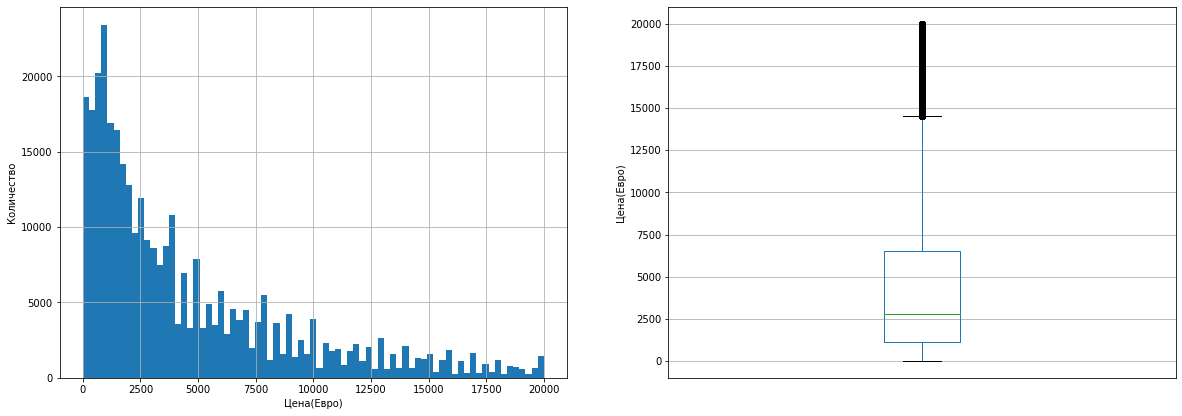

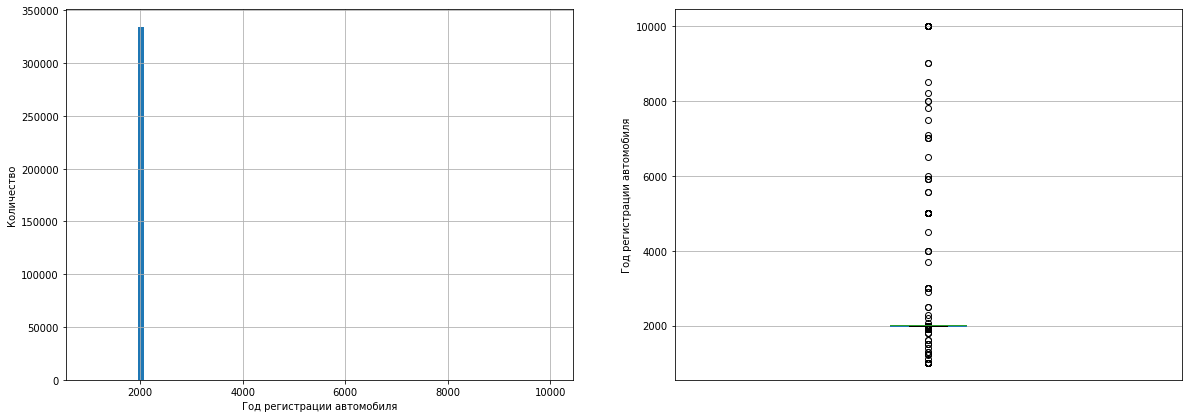

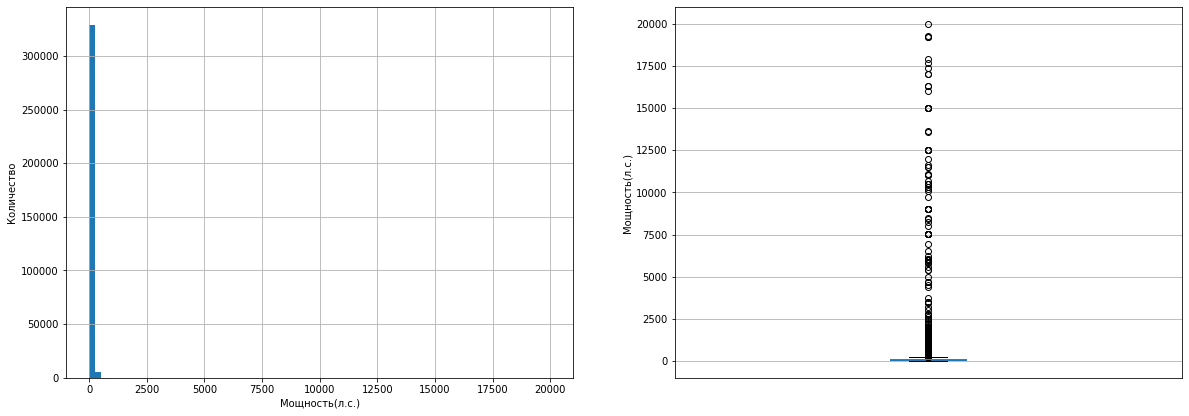

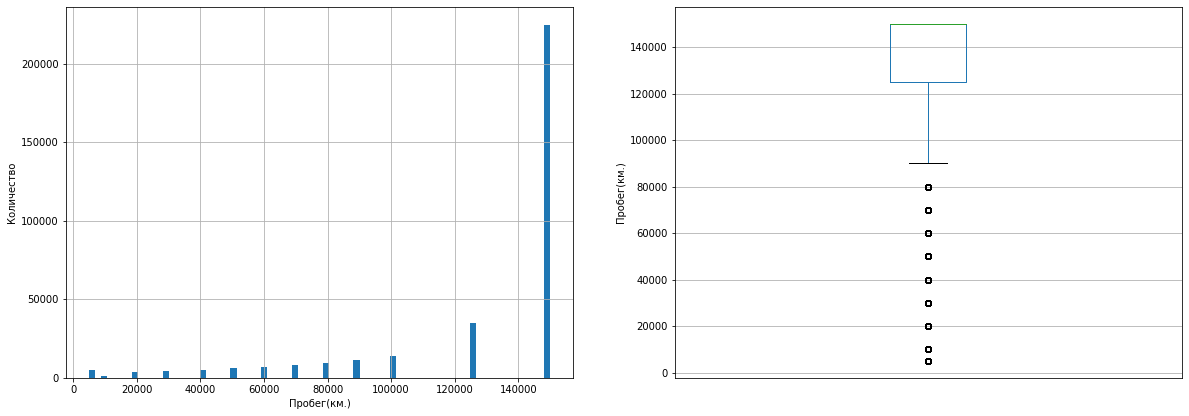

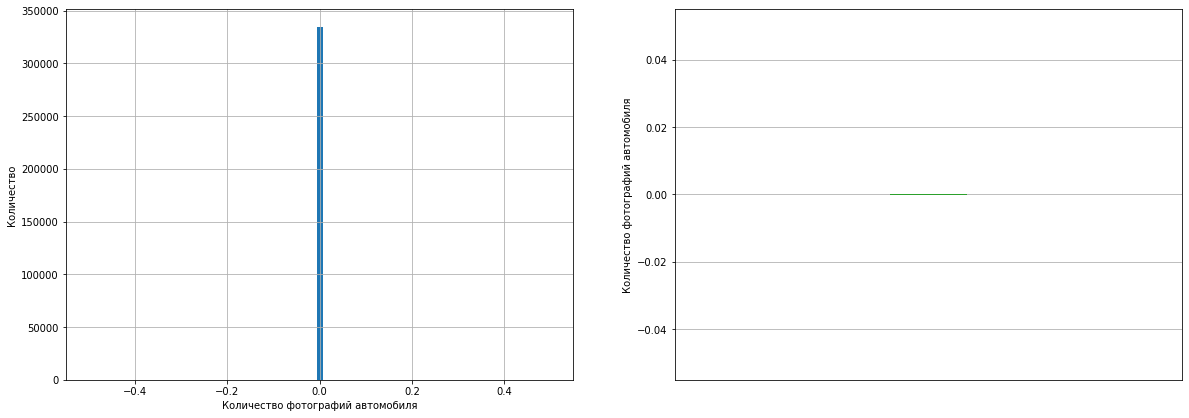

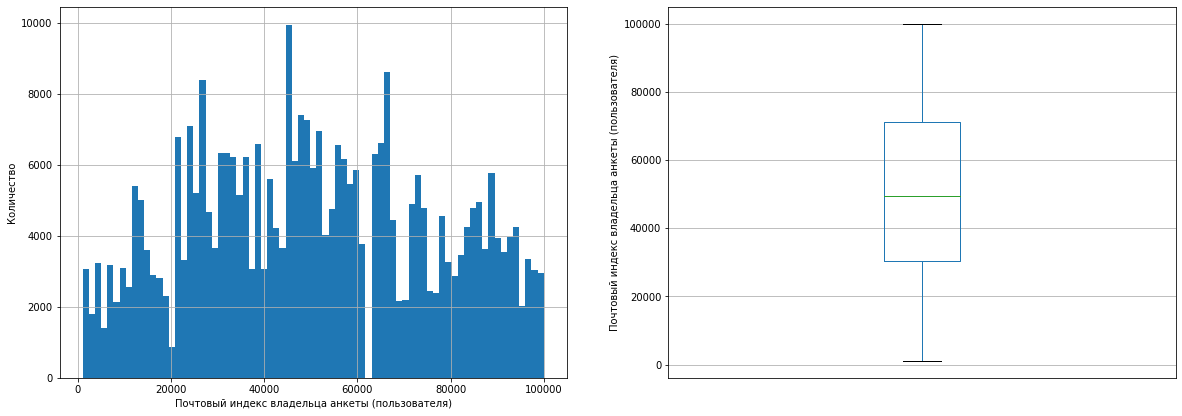

In [23]:
counting_param(autos, ['price', 'registration_year', 'power', 'kilometer', 
                       'number_of_pictures', 'postal_code'], autos_title_list,'Количество')

Из рассматриваемых данных можно говорить о следующем: столбцы `'number_of_pictures'` и `'postal_code'` никак не информативны и в дальнейшем исследовании их не стоит рассматривать.

Определим последнюю дату создания анкеты, чтобы понять границу времени:

In [24]:
autos['date_created'].max()

'2016-04-07 00:00:00'

Из гистограмм распределения можно сказать следующее: необходимо задать ограничение на мощность - так как наш салон продаёт авто обычным клиентам и явно не ориентирован на Формулу-1, то ограничим мощность известным в мире рекордом по скорости автомобиля в 1000 л.с.; года регистрации тоже ограничим с 1920 по 2016 года, потому что это последняя запись в имеющемся датафрейме. Также возьмем цены автомобилей больше 0, так как на гистограмме левая сторона графика странно высока (бесплатное авто - это хорошо, но когда его предоставляют нам, а не мы). Сделаем срез по необходимым условиям:

In [25]:
autos = autos.query('registration_year > 1920 and registration_year < 2016 and power < 1000 and power > 0 and price > 0')

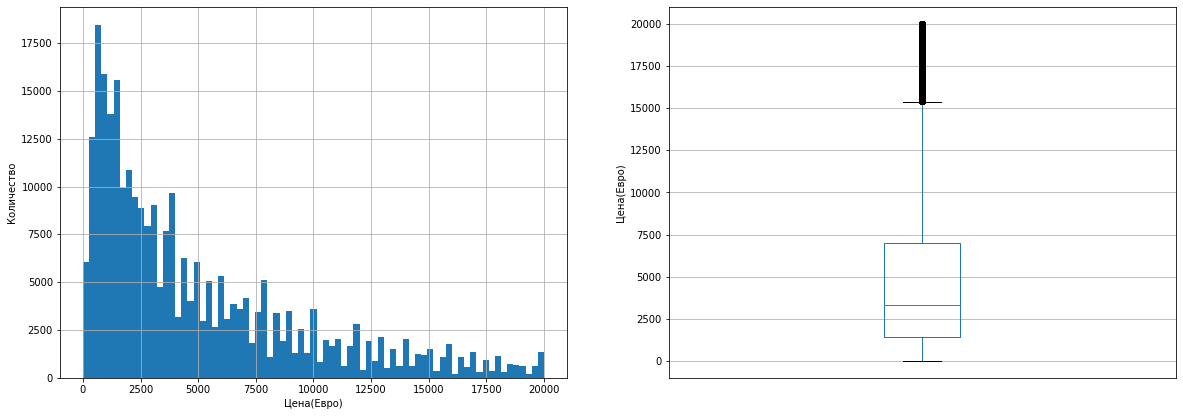

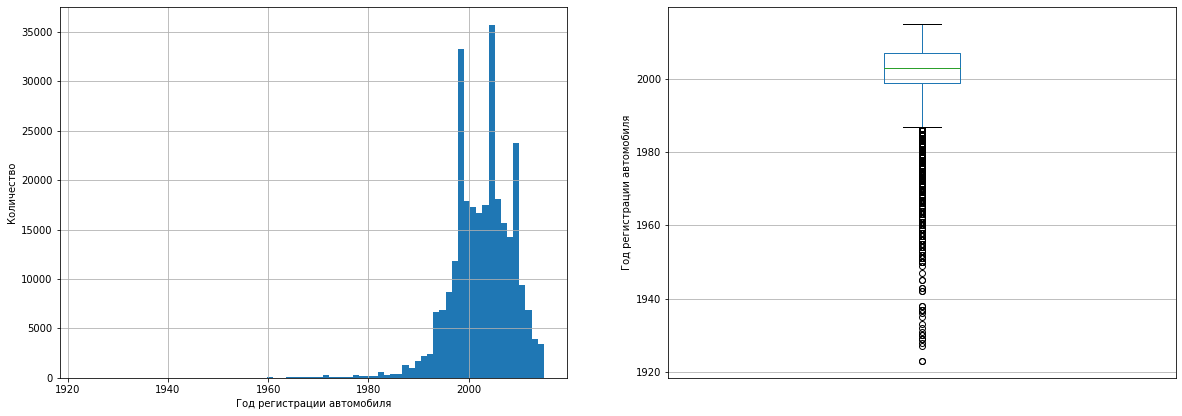

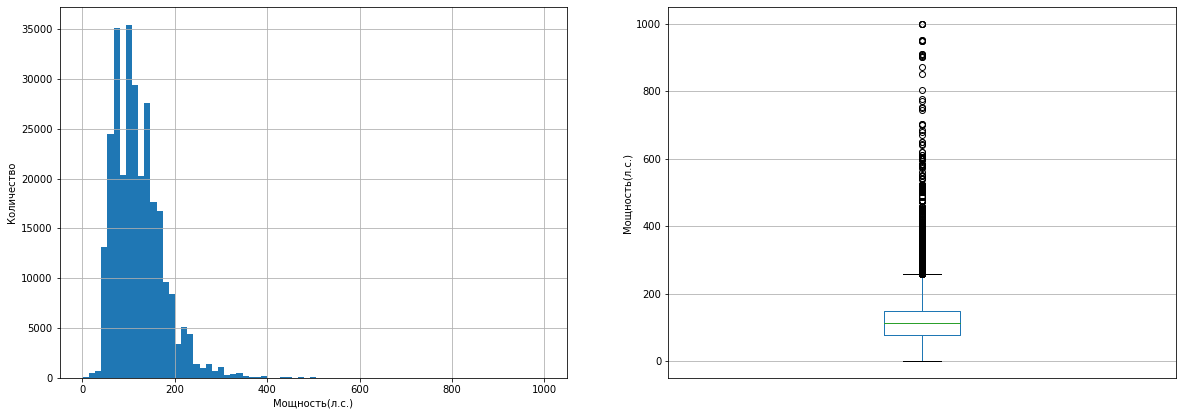

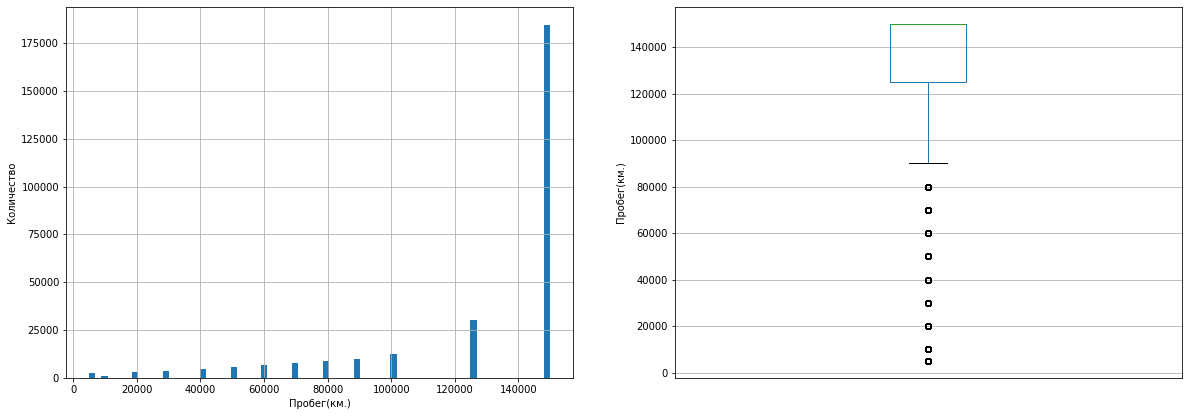

In [26]:
counting_param(autos, ['price', 'registration_year', 'power', 'kilometer'], autos_title_list,'Количество')

Из повторного рассмотрения гистограмм и диаграмм размахов видно следующее: выбросы в данных есть, и где-то достаточно много; в связи с этим **не будем** проводить **удаление выбросов**, так как их количество достаточно объемное, а также стоит отметить, что каждое авто уникально и нельзя все рассматриваемые нами автомобили разных типов и с разными двигателями подогнать под одни и те же параметры.  

#### Рассмотрим категориальные переменные

Для того чтобы подсчитать количество значений в конкретном столбце категориальных переменных, воспользуемся методом `.value_counts()`; после для наглядности выведем круговую диаграмму этих значений.

Для оптимизации напишем функцию `dataframe_diagram()`, которая будет строить и выводить круговые диаграммы; в функцию будем передавать датафрейм, список необходимых столбцов и список заголовочных названий графиков: 

In [27]:
def dataframe_diagram(dataframe, data_list, title_list):
    for i,j in zip(data_list,title_list):
        plt.figure(figsize=(20, 15))
        plt.subplot(2, 2, 1)
        dataframe[i].value_counts().sort_values(ascending=True).plot(kind='barh')
        plt.ylabel(' ')
        plt.title(j)
        plt.legend()
        plt.subplot(2, 2, 2)
        dataframe[i].value_counts().plot(kind='pie', autopct='%.2f')
        plt.ylabel(' ')
        plt.title(j)
        plt.legend(bbox_to_anchor=(1, 0.6))
        plt.show()
        print(dataframe[i].value_counts())

In [28]:
# список заголовков для графиков
cat_list = ['Tип автомобильного кузова', 'Tип коробки передач', 'Tип топлива', 'Был ремонт машины?']

Воспользуемся ранее написанной функцией `dataframe_diagram()`:

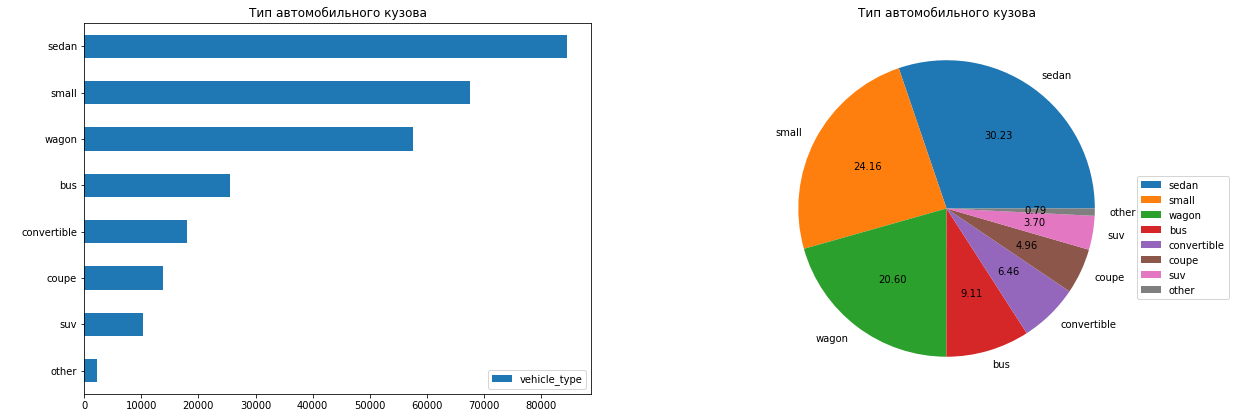

sedan          84586
small          67610
wagon          57636
bus            25492
convertible    18076
coupe          13874
suv            10341
other           2219
Name: vehicle_type, dtype: int64


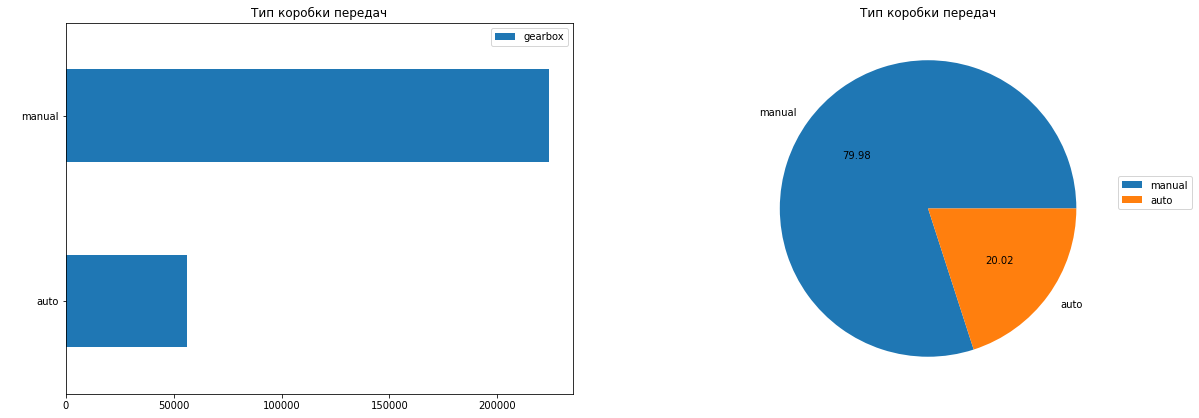

manual    223807
auto       56027
Name: gearbox, dtype: int64


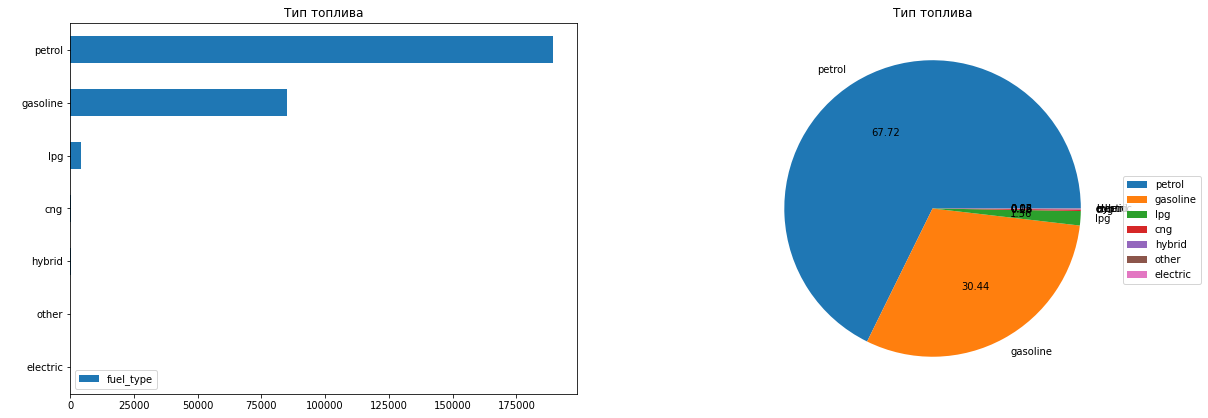

petrol      189510
gasoline     85185
lpg           4375
cng            460
hybrid         176
other           72
electric        56
Name: fuel_type, dtype: int64


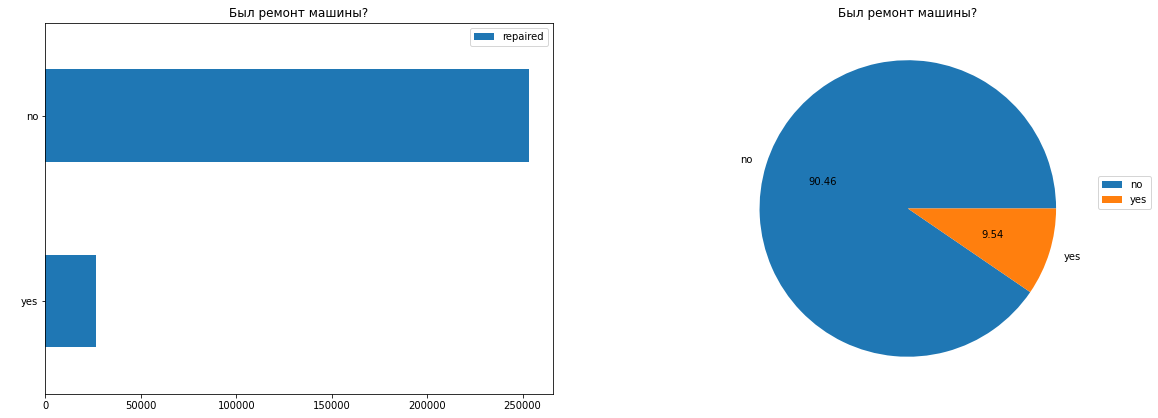

no     253133
yes     26701
Name: repaired, dtype: int64


In [29]:
dataframe_diagram(autos, ['vehicle_type', 'gearbox', 'fuel_type', 'repaired'], cat_list)

In [30]:
autos['model'].value_counts()

golf                  23891
other                 20194
3er                   17168
polo                  10369
corsa                  9820
                      ...  
i3                        5
kalina                    5
serie_3                   3
rangerover                2
range_rover_evoque        2
Name: model, Length: 249, dtype: int64

In [31]:
autos['brand'].value_counts()

volkswagen       60476
bmw              30851
opel             30556
mercedes_benz    26359
audi             24529
ford             19679
renault          13185
peugeot           8741
fiat              7240
seat              5593
skoda             4810
mazda             4443
smart             4296
citroen           4056
toyota            3872
nissan            3859
hyundai           2954
mini              2899
volvo             2723
mitsubishi        2342
honda             2222
kia               1985
alfa_romeo        1871
suzuki            1852
chevrolet         1384
chrysler          1107
dacia              777
subaru             614
porsche            609
daihatsu           587
jeep               558
saab               461
land_rover         453
jaguar             434
daewoo             376
lancia             358
rover              313
trabant            261
lada               149
Name: brand, dtype: int64

Из полученных результатов можно говорить следующее:
- топ-3 типов автомобильных кузовов: `sedan`(30.23%), `small`(24.16%), `wagon`(20.6%)
- 20% всех авто имеет автоматическую коробку передач (`auto`), остальная же часть (около 80%) - механическую (`manual`)
- более 2/3 всех авто заправляются `petrol`, 30% - `gasoline`
- у более 90% авто не было ремонта
- наиболее популярная модель втомобиля - `golf`
- наиболее популярными являются марки автомобилей: `volkswagen`, `bmw`, `opel`

#### Корреляционный анализ

**Проведём корреляционный анализ признаков в датасетах**

Изучим взаимосвязь между признаками в датафрейме `autos` - хорошим решением будет использовать коэффициент корреляции 𝜙𝐾, это передовой способ вычисления коэффициентов корреляции для любых типов признаков и не требует предварительного кодирования, этот коэффициент показывает не только линейные связи, но и нелинейные. Для этого воспользуемся методом `.phik_matrix()`, который возвращает коэффициенты корреляции 𝜙𝐾; перед этим удалим столбецы с необходимыми нам данными, так как некоторые из них просто информируют нас о чём-то и только добавляют работы. 

In [32]:
phiK_mat = autos.drop(columns=['date_crawled', 'date_created', 'number_of_pictures',
                               'registration_month', 'postal_code', 'last_seen']).phik_matrix()

interval columns not set, guessing: ['price', 'registration_year', 'power', 'kilometer']


В связи с тем, что данные у нас не непрервыные, а дискретные, то `interval columns` в `.phik_matrix()` не будем указывать.

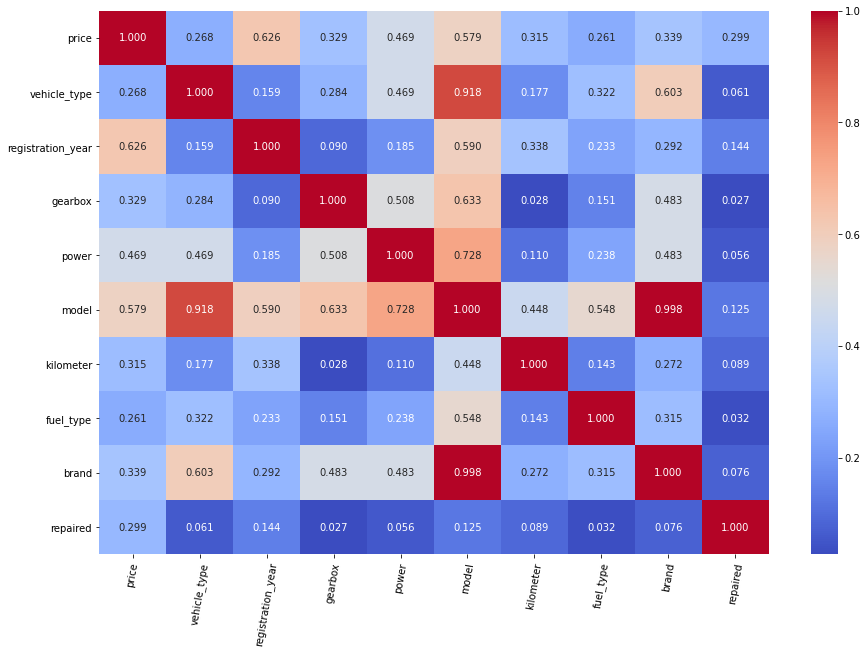

In [33]:
plt.figure(figsize=(15, 10))
sns.heatmap(phiK_mat, annot=True, fmt='.3f', cmap='coolwarm')
plt.xticks(rotation=80)
plt.show()

Из полученной тепловой карты видно, что признаки `model` - `brand` крайне сильно коррелируют между собой, что может указывать на *мультиколлинеарность*. В связи с этим удалим один из двух признаков, чтобы от этого избавиться. Удалим `brand` и снова рассмотрим тепловую карту:

In [34]:
phiK_mat = autos.drop(columns=['date_crawled', 'brand', 'date_created', 'number_of_pictures',
                               'registration_month', 'postal_code', 'last_seen']).phik_matrix()

interval columns not set, guessing: ['price', 'registration_year', 'power', 'kilometer']


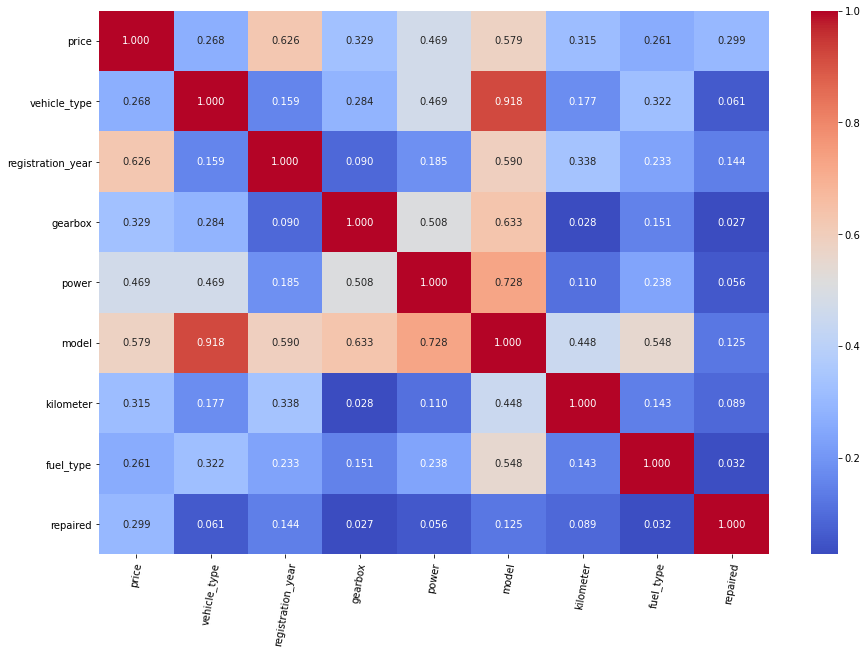

In [35]:
plt.figure(figsize=(15, 10))
sns.heatmap(phiK_mat, annot=True, fmt='.3f', cmap='coolwarm')
plt.xticks(rotation=80)
plt.show()

На тепловой карте удобно представлены результаты, по которым можно провести анализ. Согласно *шкале Чеддока* можно говорить о следующее: есть коррелирующие и некоррелирующие величины. Из тепловой карты наглядно видно: 
- **весьма высокая** связь: `'model'` - `'vehice_type'`
- **высокая** связь: '`model'`-`'power'`
- **заметная** связь: `'model'`-`'price'`, `'model'`-`'registration_year'`, `'model'`-`'gearbox'`, `'model'`-`'fuel_type'`,  `'price'`-`'registration_year'`,
- остальные признаки имеют  **умеренную** или **слабую** связь или её вообще нет 

Из повторного графика можно сказать, что говорить о **мультиколлениарности** тут уже нельзя.

В связи с этим удалим из основного датафрейма только те признаки, об исключении которых говорили ранее:

In [36]:
act_autos = autos.copy()
act_autos = act_autos.drop(columns=['date_crawled', 'brand', 'date_created', 'number_of_pictures',
                            'registration_month', 'postal_code', 'last_seen']).reset_index(drop=True)

Проверим результат - выведем первые строки:

In [37]:
act_autos.head()

,price,vehicle_type,registration_year,gearbox,power,model,kilometer,fuel_type,repaired
0,9800,suv,2004,auto,163,grand,125000,gasoline,no
1,1500,small,2001,manual,75,golf,150000,petrol,no
2,3600,small,2008,manual,69,fabia,90000,gasoline,no
3,650,sedan,1995,manual,102,3er,150000,petrol,yes
4,2200,convertible,2004,manual,109,2_reihe,150000,petrol,no


#### Сделаем выводы о данных

В результате исследования количественных признаков были получены следующие результаты:
- были проанализированы выбросы в датафрейме
- проанализировали реальные границы данных, чтобы информация была достоверной
- было проведено исследование на удаление или сохранение выбросов в результате которого было принято решение **не удалять** выбросы, так как не все графики имеют нормальное распределение, а также выбросов крайне много, что серьезно повлияет на результаты исследования

В результате исследования категориальных признаков были получены следующие результаты:
- топ-3 типов автомобильных кузовов: `sedan`(30.23%), `small`(24.16%), `wagon`(20.6%)
- 20% всех авто имеет автоматическую коробку передач (`auto`), остальная же часть (около 80%) - механическую (`manual`)
- более 2/3 всех авто заправляются `petrol`, 30% - `gasoline`
- у более 90% авто не было ремонта
- наиболее популярная модель втомобиля - `golf`
- наиболее популярными являются марки автомобилей: `volkswagen`, `bmw`, `opel`

В результате исследования корреляционного анализа были получены следующие результаты:
- построили тепловую карту матрицы корреляционных значений и проанализировали её
- сделали выводы о взаимосвязи признаков
- удалили один из мультикоррелирующих признаков

## Обучение моделей

Начнём подготовку признаков для дальнейшего обучения моделей.

Так как у нас присутствуют категориальные переменные в датафррейме, то необходимо будет закодировать их. Для этого воспользуемся функцией `.get_dummies`:

In [38]:
act_autos_ohe = pd.get_dummies(act_autos, drop_first=True)

Посмотрим на результат кодировки категориальных признаков:

In [39]:
act_autos_ohe.head()

,price,registration_year,power,kilometer,vehicle_type_convertible,vehicle_type_coupe,vehicle_type_other,vehicle_type_sedan,vehicle_type_small,vehicle_type_suv,...,model_ypsilon,model_z_reihe,model_zafira,fuel_type_electric,fuel_type_gasoline,fuel_type_hybrid,fuel_type_lpg,fuel_type_other,fuel_type_petrol,repaired_yes
0,9800,2004,163,125000,0,0,0,0,0,1,...,0,0,0,0,1,0,0,0,0,0
1,1500,2001,75,150000,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,1,0
2,3600,2008,69,90000,0,0,0,0,1,0,...,0,0,0,0,1,0,0,0,0,0
3,650,1995,102,150000,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,1,1
4,2200,2004,109,150000,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0


Данные были успешно закодированы.

Теперь разделим их на тренировочные и тестовые выборки.

Деление и сохранение на тренировочную, валидационную и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(act_autos_ohe.drop(['price'], axis=1), 
                                                    act_autos_ohe['price'], 
                                                    test_size = TEST_SIZE, 
                                                    random_state = RANDOM_STATE)

In [40]:
# Деление и сохранение данных на тестовую и временную выборки
X_temp, X_test, y_temp, y_test = train_test_split(act_autos_ohe.drop(['price'], axis=1), 
                                                  act_autos_ohe['price'], 
                                                  test_size=TEST_SIZE, 
                                                  random_state=RANDOM_STATE)


In [41]:
# Деление временной выборки на тренировочную и валидационную выборки
X_train, X_valid, y_train, y_valid = train_test_split(X_temp, 
                                                      y_temp, 
                                                      test_size=VAL_SIZE, 
                                                      random_state=RANDOM_STATE)

In [42]:
# Размеры тренировочных и тестовых выборкок
X_train.shape, X_valid.shape, X_test.shape

((167900, 266), (55967, 266), (55967, 266))

Запишем количественные столбцы в переменную `num_col_names`:

In [43]:
num_col_names = list(act_autos_ohe.columns)
num_col_names.remove('price')

In [44]:
# Подготовка признаков (масштабирование)

# Создадим переменную с экземпляром класса StandardScaler()
scaler = StandardScaler()

# Tрансформируем количественные признаки
X_train[num_col_names] = scaler.fit_transform(X_train[num_col_names])
X_valid[num_col_names] = scaler.transform(X_valid[num_col_names])
X_test[num_col_names] = scaler.transform(X_test[num_col_names])

/tmp/ipykernel_195/1506859818.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train[num_col_names] = scaler.fit_transform(X_train[num_col_names])
/opt/conda/lib/python3.9/site-packages/pandas/core/indexing.py:1738: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_single_column(loc, value[:, i].tolist(), pi)
/tmp/ipykernel_195/1506859818.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

S

Проверим масштабирование выборок:

In [45]:
X_train.head()

,registration_year,power,kilometer,vehicle_type_convertible,vehicle_type_coupe,vehicle_type_other,vehicle_type_sedan,vehicle_type_small,vehicle_type_suv,vehicle_type_wagon,...,model_ypsilon,model_z_reihe,model_zafira,fuel_type_electric,fuel_type_gasoline,fuel_type_hybrid,fuel_type_lpg,fuel_type_other,fuel_type_petrol,repaired_yes
230688,-2.700295,-1.312559,-0.089067,-0.262389,-0.229286,-0.088643,-0.658090,1.765392,-0.194646,-0.508093,...,-0.02429,-0.048499,-0.094816,-0.013807,-0.661289,-0.025134,-0.12644,-0.016005,0.690147,-0.324852
51458,1.352780,0.772139,0.594820,-0.262389,-0.229286,-0.088643,-0.658090,-0.566446,-0.194646,1.968143,...,-0.02429,-0.048499,-0.094816,-0.013807,1.512198,-0.025134,-0.12644,-0.016005,-1.448966,-0.324852
223473,0.542165,-0.113396,0.594820,-0.262389,-0.229286,-0.088643,-0.658090,-0.566446,-0.194646,1.968143,...,-0.02429,-0.048499,-0.094816,-0.013807,1.512198,-0.025134,-0.12644,-0.016005,-1.448966,-0.324852
155464,-0.106327,0.274026,0.594820,-0.262389,-0.229286,-0.088643,1.519548,-0.566446,-0.194646,-0.508093,...,-0.02429,-0.048499,-0.094816,-0.013807,-0.661289,-0.025134,-0.12644,-0.016005,0.690147,-0.324852
58274,-0.106327,-0.205639,0.594820,-0.262389,4.361360,-0.088643,-0.658090,-0.566446,-0.194646,-0.508093,...,-0.02429,-0.048499,-0.094816,-0.013807,1.512198,-0.025134,-0.12644,-0.016005,-1.448966,-0.324852


In [46]:
X_valid.head()

,registration_year,power,kilometer,vehicle_type_convertible,vehicle_type_coupe,vehicle_type_other,vehicle_type_sedan,vehicle_type_small,vehicle_type_suv,vehicle_type_wagon,...,model_ypsilon,model_z_reihe,model_zafira,fuel_type_electric,fuel_type_gasoline,fuel_type_hybrid,fuel_type_lpg,fuel_type_other,fuel_type_petrol,repaired_yes
45932,-0.754819,-0.851342,0.594820,-0.262389,-0.229286,-0.088643,-0.658090,1.765392,-0.194646,-0.508093,...,-0.02429,-0.048499,-0.094816,-0.013807,-0.661289,-0.025134,-0.12644,-0.016005,0.690147,-0.324852
97575,1.677025,-0.851342,-2.687836,-0.262389,-0.229286,-0.088643,-0.658090,-0.566446,-0.194646,1.968143,...,-0.02429,-0.048499,-0.094816,-0.013807,1.512198,-0.025134,-0.12644,-0.016005,-1.448966,-0.324852
175363,-0.592696,-0.390126,0.594820,-0.262389,-0.229286,-0.088643,-0.658090,-0.566446,-0.194646,1.968143,...,-0.02429,-0.048499,-0.094816,-0.013807,-0.661289,-0.025134,-0.12644,-0.016005,0.690147,-0.324852
79385,-0.916942,-0.279434,0.594820,-0.262389,-0.229286,-0.088643,-0.658090,1.765392,-0.194646,-0.508093,...,-0.02429,-0.048499,-0.094816,-0.013807,-0.661289,-0.025134,-0.12644,-0.016005,0.690147,-0.324852
67238,1.190657,2.561659,0.594820,-0.262389,-0.229286,-0.088643,1.519548,-0.566446,-0.194646,-0.508093,...,-0.02429,-0.048499,-0.094816,-0.013807,-0.661289,-0.025134,-0.12644,-0.016005,0.690147,-0.324852


In [47]:
X_test.head()

,registration_year,power,kilometer,vehicle_type_convertible,vehicle_type_coupe,vehicle_type_other,vehicle_type_sedan,vehicle_type_small,vehicle_type_suv,vehicle_type_wagon,...,model_ypsilon,model_z_reihe,model_zafira,fuel_type_electric,fuel_type_gasoline,fuel_type_hybrid,fuel_type_lpg,fuel_type_other,fuel_type_petrol,repaired_yes
183367,-0.106327,0.772139,0.59482,-0.262389,-0.229286,-0.088643,-0.658090,-0.566446,-0.194646,1.968143,...,-0.02429,-0.048499,-0.094816,-0.013807,1.512198,-0.025134,-0.12644,-0.016005,-1.448966,-0.324852
93256,-0.268450,-0.094948,0.59482,-0.262389,-0.229286,-0.088643,1.519548,-0.566446,-0.194646,-0.508093,...,-0.02429,-0.048499,-0.094816,-0.013807,1.512198,-0.025134,-0.12644,-0.016005,-1.448966,-0.324852
37599,-0.592696,-1.312559,0.59482,-0.262389,-0.229286,-0.088643,-0.658090,1.765392,-0.194646,-0.508093,...,-0.02429,-0.048499,-0.094816,-0.013807,-0.661289,-0.025134,-0.12644,-0.016005,0.690147,-0.324852
189610,-0.268450,-1.164970,0.59482,-0.262389,-0.229286,-0.088643,-0.658090,1.765392,-0.194646,-0.508093,...,-0.02429,-0.048499,-0.094816,-0.013807,-0.661289,-0.025134,-0.12644,-0.016005,0.690147,3.078323
31190,-0.754819,-0.574613,0.59482,-0.262389,-0.229286,-0.088643,-0.658090,-0.566446,-0.194646,1.968143,...,-0.02429,-0.048499,-0.094816,-0.013807,-0.661289,-0.025134,-0.12644,-0.016005,0.690147,-0.324852


Масштабирование было успешно проведено.

Перед работой с разными моделями создадим списки, куда будем записывать их результаты, чтобы после было проще проанализировать и сравнить данные: 

In [48]:
# Создаем пустые списки для таблицы результатов 
models = []
rmse_result = []
train_time = []
predict_time = []

### Модель LinearRegression()

Рассмотрим одну и наиболее часто применимых моделей за весь наш курс - LinearRegression():

In [49]:
%%time
# Инициализируем модель линейной регрессии
lin_model = LinearRegression()

models.append(lin_model)

CPU times: user 39 µs, sys: 7 µs, total: 46 µs
Wall time: 51.3 µs


In [50]:
start_time = time.time()

# Обучим модель на тренировочных данных
lin_model.fit(X_train, y_train)

end_time = time.time()
execution_time = end_time - start_time
train_time.append(execution_time)
print('Время обучения:', execution_time)

Время обучения: 15.498631000518799


In [51]:
start_time = time.time()

# Получим предсказания модели на валидационных данных 
# и сохраним результат в predictions_lin_model
y_pred_lin_model = lin_model.predict(X_valid)

end_time = time.time()
execution_time = end_time - start_time
predict_time.append(execution_time)
print('Время предсказания:', execution_time)

Время предсказания: 0.1730811595916748


In [52]:
%%time
# Вычисление RMSE
rmse = np.sqrt(mean_squared_error(y_valid, y_pred_lin_model))
print('Метрика RMSE для модели LinearRegression():', round(rmse,5))
rmse_result.append(rmse)

Метрика RMSE для модели LinearRegression(): 2561.81899
CPU times: user 8.48 ms, sys: 26 ms, total: 34.4 ms
Wall time: 5.83 ms


В результате видно, что значение метрики RMSE получилось немного больше, чем должно быть; но сама модель построилась весьма быстро.   

### Модель DecisionTreeRegressor()

Рассмотрим следующую модель для обучения `DecisionTreeRegressor()`:

In [53]:
%%time
# Инициализируем модель DecisionTreeRegressor()
dtr_model = DecisionTreeRegressor(random_state=RANDOM_STATE)

models.append(dtr_model)

CPU times: user 56 µs, sys: 0 ns, total: 56 µs
Wall time: 59.1 µs


In [54]:
start_time = time.time()

# Обучим модель на тренировочных данных
dtr_model.fit(X_train, y_train)

end_time = time.time()
execution_time = end_time - start_time
train_time.append(execution_time)
print('Время обучения:', execution_time)

Время обучения: 4.006505250930786


In [55]:
start_time = time.time()

# Получим предсказания модели на валидационных данных 
# и сохраним результат в y_pred_dtr_model
y_pred_dtr_model = dtr_model.predict(X_valid)

end_time = time.time()
execution_time = end_time - start_time
predict_time.append(execution_time)
print('Время предсказания:', execution_time)

Время предсказания: 0.08291864395141602


In [56]:
%%time
# Вычисление RMSE
rmse = np.sqrt(mean_squared_error(y_valid, y_pred_dtr_model))
print('Метрика RMSE для модели DecisionTreeRegressor():', round(rmse,5))
rmse_result.append(rmse)

Метрика RMSE для модели DecisionTreeRegressor(): 1865.16383
CPU times: user 3.7 ms, sys: 0 ns, total: 3.7 ms
Wall time: 2.21 ms


Полученный результат метрики RMSE уже лучше и удовллетворяет требованию быть меньше 2500.

Теперь постараемся подобрать гиперпараметры для улучшения метирки RMSE. Рассмотрим модель `DecisionTreeRegressor()` с гипермараметрами:
- `max_depth` - максимальная глубина дерева

In [57]:
%%time
for depth in range(5, 20):
    
    research_model = DecisionTreeRegressor(random_state=RANDOM_STATE, max_depth = depth)
    research_model.fit(X_train, y_train)
    y_pred_research_model = research_model.predict(X_valid)
    
    rmse = np.sqrt(mean_squared_error(y_valid, y_pred_research_model))
    print('Гиперпараметр depth:', depth)
    print('Метрика RMSE для исследуемой модели DecisionTreeRegressor():', round(rmse,5), '\n')
print()

Гиперпараметр depth: 5
Метрика RMSE для исследуемой модели DecisionTreeRegressor(): 2333.69932 

Гиперпараметр depth: 6
Метрика RMSE для исследуемой модели DecisionTreeRegressor(): 2225.51372 

Гиперпараметр depth: 7
Метрика RMSE для исследуемой модели DecisionTreeRegressor(): 2136.50802 

Гиперпараметр depth: 8
Метрика RMSE для исследуемой модели DecisionTreeRegressor(): 2070.28185 

Гиперпараметр depth: 9
Метрика RMSE для исследуемой модели DecisionTreeRegressor(): 2015.58596 

Гиперпараметр depth: 10
Метрика RMSE для исследуемой модели DecisionTreeRegressor(): 1981.32157 

Гиперпараметр depth: 11
Метрика RMSE для исследуемой модели DecisionTreeRegressor(): 1949.89205 

Гиперпараметр depth: 12
Метрика RMSE для исследуемой модели DecisionTreeRegressor(): 1925.26147 

Гиперпараметр depth: 13
Метрика RMSE для исследуемой модели DecisionTreeRegressor(): 1901.14976 

Гиперпараметр depth: 14
Метрика RMSE для исследуемой модели DecisionTreeRegressor(): 1887.70186 

Гиперпараметр depth: 15
М

Из результата поиска по подбору гиперпараметра `max_depth` видно, что результат не сильно улучшился по сравнению с ранее полученной метрикой RMSE. Поэтому для анализа будем рассматривать модель ранее, в которой гиперпараметры были по умолчанию. 

### Модель LGBMRegressor()

Изучив и установив библиотеку LightGBM, построим модель LGBMRegressor(). В связи с некоторыми особенностями, необходимо изменить входные данные для модели при делении на выборки:

In [58]:
act_autos_lgbm = act_autos.copy()
act_autos_lgbm = act_autos_lgbm.astype({'vehicle_type':'category',
                                        'gearbox':'category',
                                        'model':'category',
                                        'fuel_type':'category',
                                        'repaired':'category'})

In [59]:
# Деление и сохранение данных на тестовую и временную выборки
X_temp_lgbm, X_test_lgbm, y_temp_lgbm, y_test_lgbm = train_test_split(act_autos_lgbm.drop(['price'], axis=1), 
                                                                      act_autos_lgbm['price'], 
                                                                      test_size = TEST_SIZE, 
                                                                      random_state = RANDOM_STATE)


In [60]:
# Деление временной выборки на тренировочную и валидационную выборки
X_train_lgbm, X_valid_lgbm, y_train_lgbm, y_valid_lgbm = train_test_split(X_temp_lgbm, 
                                                                          y_temp_lgbm, 
                                                                          test_size=VAL_SIZE, 
                                                                          random_state=RANDOM_STATE)

In [61]:
X_train_lgbm.shape, X_valid_lgbm.shape, X_test_lgbm.shape

((167900, 8), (55967, 8), (55967, 8))

Количество строк в тренировочной, валидационной и тестовой выборкок для модели LGBMRegressor() совпадает по строка с выборками, для которых применялось масштабирование и кодирование для моделей ранее.

In [62]:
%%time
# Инициализируем модель LGBMRegressor()
lgbm_model = lgb.LGBMRegressor(random_state = RANDOM_STATE)

models.append(lgbm_model)

CPU times: user 97 µs, sys: 14 µs, total: 111 µs
Wall time: 115 µs


In [63]:
start_time = time.time()

# Обучим модель на тренировочных данных
lgbm_model.fit(X_train_lgbm, y_train_lgbm)

end_time = time.time()
execution_time = end_time - start_time
train_time.append(execution_time)
print('Время обучения:', execution_time)

Время обучения: 210.79622602462769


In [64]:
start_time = time.time()

# Получим предсказания модели на валидационных данных 
# и сохраним результат в y_pred_lgbm_model
y_pred_lgbm_model = lgbm_model.predict(X_valid_lgbm)

end_time = time.time()
execution_time = end_time - start_time
predict_time.append(execution_time)
print('Время предсказания:', execution_time)

Время предсказания: 0.677978515625


In [65]:
%%time
# Вычисление RMSE
rmse = np.sqrt(mean_squared_error(y_valid_lgbm, y_pred_lgbm_model))
print('Метрика RMSE для модели LGBMRegressor():', round(rmse,5))
rmse_result.append(rmse)

Метрика RMSE для модели LGBMRegressor(): 1604.89355
CPU times: user 3.49 ms, sys: 0 ns, total: 3.49 ms
Wall time: 2.1 ms


Попробуем подобрать возможные гиперпараметры для улучшения метрики RMSE:

In [66]:
param_grid = {'max_depth': [5,7,9], 'n_estimators': [100, 250, 500, 750]}

С помощью GridSearchCV я осуществлял поиск лучших гиперпараметров, однако этот поиск осуществлялся более 6 часов:(возможно причина в перегрузке на платформе, так как у других одногруппников это было чуть быстрее; но, на мой взгляд, лучше не перезапускать ячейку ниже)

In [75]:
%%time
research = GridSearchCV(
        lgbm_model,
        param_grid,
        n_jobs=-1,
        cv=3,
        scoring='neg_root_mean_squared_error',
        verbose=1
        )

# обучение модели
research.fit(X_train, y_train)
print('Лучшие подобранные гиперпараметры исследованных моделей:', research.best_params_)
print('Лучшая метрика RMSE исследованных моделей:', (-1) * research.best_score_)

Fitting 3 folds for each of 12 candidates, totalling 36 fits
{'max_depth': 9, 'n_estimators': 750}
1568.8061540999206
CPU times: user 6h 30min 50s, sys: 2min 29s, total: 6h 33min 20s
Wall time: 6h 35min 25s


После выполнения мы получили следующие лучшие гиперпараметры `'max_depth'`: `9`, `'n_estimators'`: `750`; и следующее значение метрики RMSE - `1568.80615`. При сравнении с результатом метрики в модели с гиперпараметрами по умолчанию можно сказать, что результат некритически отличается друг от друга. В связи с этим при сравнении моделей будем рассматривать модель `LGBMRegressor()` с гиперпараметрами по умолчанию. 

### Модель RandomForestRegressor()

Рассмотрим модель `RandomForestRegressor()`:

In [67]:
%%time
# Инициализируем модель RandomForestRegressor()
rfr_model = RandomForestRegressor(random_state=RANDOM_STATE)

models.append(rfr_model)

CPU times: user 78 µs, sys: 4 µs, total: 82 µs
Wall time: 85.8 µs


In [68]:
start_time = time.time()

# Обучим модель на тренировочных данных
rfr_model.fit(X_train, y_train)

end_time = time.time()
execution_time = end_time - start_time
train_time.append(execution_time)
print('Время обучения:', execution_time)

Время обучения: 257.4632394313812


In [69]:
start_time = time.time()

# Получим предсказания модели на валидационных данных 
# и сохраним результат в y_pred_rfr_model
y_pred_rfr_model = rfr_model.predict(X_valid)

end_time = time.time()
execution_time = end_time - start_time
predict_time.append(execution_time)
print('Время предсказания:', execution_time)

Время предсказания: 2.8402774333953857


In [70]:
%%time
# Вычисление RMSE
rmse = np.sqrt(mean_squared_error(y_valid, y_pred_rfr_model))
print('Метрика RMSE для модели RandomForestRegressor():', round(rmse,5))
rmse_result.append(rmse)

Метрика RMSE для модели RandomForestRegressor(): 1605.56313
CPU times: user 4.26 ms, sys: 3 µs, total: 4.27 ms
Wall time: 2.45 ms


Попробуем подобрать для модели `RandomForestRegressor()` гипермараметр:
- `max_depth` - максимальная глубина дерева

/// Поиск гиперпараметра на RandomForestRegressor занял 38 мин

In [65]:
%%time
for depth in range(5, 15):
        research_model = RandomForestRegressor(random_state=RANDOM_STATE, max_depth = depth)
        research_model.fit(X_train, y_train)
        y_pred_research_model = research_model.predict(X_valid)
                
        rmse = np.sqrt(mean_squared_error(y_valid, y_pred_research_model))
        print('Гиперпараметр depth:', depth)
        print('Метрика RMSE для исследуемой модели RandomForestRegressor():', round(rmse,5), '\n')
print()

Гиперпараметр depth: 5
Метрика RMSE для исследуемой модели RandomForestRegressor(): 2304.29987 

Гиперпараметр depth: 6
Метрика RMSE для исследуемой модели RandomForestRegressor(): 2193.66129 

Гиперпараметр depth: 7
Метрика RMSE для исследуемой модели RandomForestRegressor(): 2094.00665 

Гиперпараметр depth: 8
Метрика RMSE для исследуемой модели RandomForestRegressor(): 2014.06209 

Гиперпараметр depth: 9
Метрика RMSE для исследуемой модели RandomForestRegressor(): 1948.90359 

Гиперпараметр depth: 10
Метрика RMSE для исследуемой модели RandomForestRegressor(): 1892.97896 

Гиперпараметр depth: 11
Метрика RMSE для исследуемой модели RandomForestRegressor(): 1845.34006 

Гиперпараметр depth: 12
Метрика RMSE для исследуемой модели RandomForestRegressor(): 1801.44285 

Гиперпараметр depth: 13
Метрика RMSE для исследуемой модели RandomForestRegressor(): 1763.79589 

Гиперпараметр depth: 14
Метрика RMSE для исследуемой модели RandomForestRegressor(): 1729.30315 


CPU times: user 37min 32

При попытке подобрать лучше гиперпараметр можно наблюдать, что результаты метрики RMSE не улучшились, поэтому в дальнейшем будем рассматривать модель `RandomForestRegressor()` с исходными гиперпараметрами.

Запишем в `datatable` результаты проведенных исследований по обучению, предсказанию моделей, а также по полученным метрикам RMSE:

In [71]:
# данные об исследованных моделей
datatable = {
    'model': models,
    'rmse_result': rmse_result,
    'train_time': train_time,
    'predict_time': predict_time,
}

Преобразуем теперь данные в датафрейм:

In [72]:
result_table = pd.DataFrame(datatable)
result_table

,model,rmse_result,train_time,predict_time
0,LinearRegression(),2561.818992,15.498631,0.173081
1,DecisionTreeRegressor(random_state=42),1865.163826,4.006505,0.082919
2,LGBMRegressor(random_state=42),1604.893550,210.796226,0.677979
3,"(DecisionTreeRegressor(max_features='auto', ra...",1605.563127,257.463239,2.840277


**Промежуточный вывод:**

В результате обучения моделей было выполнено и получено следующее:
- выбраны модели для обучения: `LinearRegression()`, `DecisionTreeRegressor()`, `LGBMRegressor()`, `RandomForestRegressor()`
- данные разбиты на тренировочную и тестовую выборки
- проведено масштабирование и кодирование данных при необходимости для определенной модели
- проведено обучение и предсказание для моделей
- вычислено значение метрики RMSE
- сформирован датафрейм с результатами исследований моделей

## Анализ моделей

Рассмотрим ранее сформированный датафрейм с результатми моделей:

In [73]:
result_table

,model,rmse_result,train_time,predict_time
0,LinearRegression(),2561.818992,15.498631,0.173081
1,DecisionTreeRegressor(random_state=42),1865.163826,4.006505,0.082919
2,LGBMRegressor(random_state=42),1604.893550,210.796226,0.677979
3,"(DecisionTreeRegressor(max_features='auto', ra...",1605.563127,257.463239,2.840277


Напомним ещё раз критерии, которые важны заказчику:
- качество предсказания
- время обучения модели*
- время предсказания модели*

Также дополним эти критерии тем, что значение метрики RMSE должно быть меньше 2500.

*- при каждом перезапуске ядра получались различные данные по времени обучения и предсказания

In [74]:
# сортировка по метрике RMSE
result_table.query('rmse_result < 2500').sort_values(by='rmse_result')

,model,rmse_result,train_time,predict_time
2,LGBMRegressor(random_state=42),1604.893550,210.796226,0.677979
3,"(DecisionTreeRegressor(max_features='auto', ra...",1605.563127,257.463239,2.840277
1,DecisionTreeRegressor(random_state=42),1865.163826,4.006505,0.082919


Видно, что наиболее лучшие значения метрик RMSE у моделей:
- `RandomForestRegressor()` - 1566.738859
- `LGBMRegressor()` - 1600.886528

In [75]:
# сортировка по времени обучения
result_table.query('rmse_result < 2500').sort_values(by='train_time')

,model,rmse_result,train_time,predict_time
1,DecisionTreeRegressor(random_state=42),1865.163826,4.006505,0.082919
2,LGBMRegressor(random_state=42),1604.893550,210.796226,0.677979
3,"(DecisionTreeRegressor(max_features='auto', ra...",1605.563127,257.463239,2.840277


По времени обучения лучшими уже оказались модели:
- `DecisionTreeRegressor()` - 5.49362 секунд
- `LGBMRegressor()` - 286.943636 секунд (при самом первом запуске было 4.29912 секунд)

In [76]:
# сортировка по времени предсказания
result_table.query('rmse_result < 2500').sort_values(by='predict_time')

,model,rmse_result,train_time,predict_time
1,DecisionTreeRegressor(random_state=42),1865.163826,4.006505,0.082919
2,LGBMRegressor(random_state=42),1604.893550,210.796226,0.677979
3,"(DecisionTreeRegressor(max_features='auto', ra...",1605.563127,257.463239,2.840277


По времени предсказания модели видно, что лучшими являются:
- `DecisionTreeRegressor()` - 0.102723 секунд
- `LGBMRegressor()` - 0.698603 секунд

**Обобщим промежуточные результаты:**
- наиболее лучшие метрики качества предсказания у моделей:
    - `RandomForestRegressor()` - 1566.738859
    - `LGBMRegressor()` - 1600.886528
- наилучшее время обучения моделей:
    - `DecisionTreeRegressor()` - 5.49362 секунд
    - `LGBMRegressor()` - 286.943636 секунд (при самом первом запуске было 4.29912 секунд)
- наилучшее время предсказания моделей:
    - `DecisionTreeRegressor()` - 0.102723 секунд
    - `LGBMRegressor()` - 0.698603 секунд
    
Исходя из проведенного анализа, можно говорить, что модель `LGBMRegressor()` наиболее лучше подойдет для предсказания стоимости автомобилей.   

Проверим выбранную нами лучшую модель на тестовых данных и посмотрим на график рассеяния тестовых и предсказанных данных:

In [77]:
# Инициализируем модель LGBMRegressor()
lgbm_model = lgb.LGBMRegressor(random_state = RANDOM_STATE)

In [78]:
start_time = time.time()

# Обучим модель на тренировочных данных
lgbm_model.fit(X_train_lgbm, y_train_lgbm)

end_time = time.time()
execution_time = end_time - start_time
train_time.append(execution_time)
print('Время обучения:', execution_time)

Время обучения: 191.65435075759888


In [79]:
start_time = time.time()

# Получим предсказания модели на тестовых данных 
# и сохраним результат в y_pred_lgbm_model
y_pred_lgbm_model = lgbm_model.predict(X_test_lgbm)

end_time = time.time()
execution_time = end_time - start_time
predict_time.append(execution_time)
print('Время предсказания:', execution_time)

Время предсказания: 0.6245074272155762


In [80]:
%%time
# Вычисление RMSE
rmse = np.sqrt(mean_squared_error(y_test_lgbm, y_pred_lgbm_model))
print('Метрика RMSE для модели LGBMRegressor():', round(rmse,5))
rmse_result.append(rmse)

Метрика RMSE для модели LGBMRegressor(): 1602.85959
CPU times: user 0 ns, sys: 4.91 ms, total: 4.91 ms
Wall time: 4.39 ms


Результат метрики RMSE на тестовых данных приблизительно похож на результат у валидационных, что является хорошим показателем.

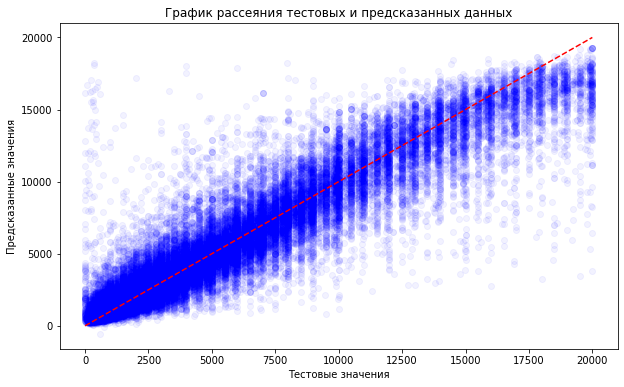

In [81]:
# график рассеяния
plt.figure(figsize=(10, 6))
plt.scatter(y_test_lgbm, y_pred_lgbm_model, color='blue', alpha=0.05)
plt.plot([min(y_test_lgbm), max(y_test_lgbm)], [min(y_test_lgbm), max(y_test_lgbm)], color='red', linestyle='--')
plt.xlabel('Тестовые значения')
plt.ylabel('Предсказанные значения')
plt.title('График рассеяния тестовых и предсказанных данных')
plt.show()

Из визуализации графика можно говорить о следующем:
- модель хорошо предсказывает значения, так как большинство точек находятся близко к линии соответствия, что указывает на высокую точность модели
- ошибки предсказания в основном небольшие, но в некоторых областях они могут быть больше
- плотность точек увеличивается с увеличением тестовых значений

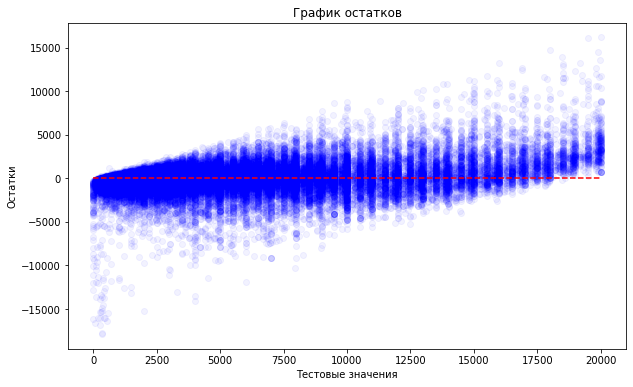

In [82]:
# график остатков
plt.figure(figsize=(10, 6))
plt.scatter(y_test_lgbm, (y_test_lgbm - y_pred_lgbm_model), color='blue', alpha=0.05)
plt.hlines(y=0, xmin=min(y_test_lgbm), xmax=max(y_test_lgbm), color='red', linestyle='--')
plt.xlabel('Тестовые значения')
plt.ylabel('Остатки')
plt.title('График остатков')
plt.show()

Из результата визуализации данных можно говорить о следующем:
- большинство остатков находятся близко к нулю, что указывает на высокую точность модели
- плотность остатков увеличивается с увеличением тестовых значений

## Общий вывод по исследованию

Сформулируем общий вывод из проведенного нами исследования:

- Загрузка данных:
    - считали CSV-файл 
- Предобработка данных:
    - изучили основную информацию о датафрейме
    - определили, что типы данных соответствуют действительности
    - привели названия столбцов к правильному виду - прописные буквы, "змеевидная" запись(через нижнее подчеркивание), латинский алфавит
    - обработали пропуски в столбцах датафрейма
    - проверили и проанализировали данные на наличие дубликатов как явных, так и неявных
    - удалили дубликаты там, где это было возможно
- Исследовательский анализ данных:
    - В результате исследования количественных признаков были получены следующие результаты:
        - были проанализированы выбросы в датафрейме
        - проанализировали реальные границы данных, чтобы информация была достоверной
        - было проведено исследование на удаление или сохранение выбросов в результате которого было принято решение **не удалять** выбросы, так как не все графики имеют нормальное распределение, а также выбросов крайне много, что серьезно повлияет на результаты исследования

    - В результате исследования категориальных признаков были получены следующие результаты:
        - топ-3 типов автомобильных кузовов: `sedan`(30.23%), `small`(24.16%), `wagon`(20.6%)
        - 20% всех авто имеет автоматическую коробку передач (`auto`), остальная же часть (около 80%) - механическую (`manual`)
        - более 2/3 всех авто заправляются `petrol`, 30% - `gasoline`
        - у более 90% авто не было ремонта
        - наиболее популярная модель втомобиля - `golf`
        - наиболее популярными являются марки автомобилей: `volkswagen`, `bmw`, `opel`

    - В результате исследования корреляционного анализа были получены следующие результаты:
        - построили тепловую карту матрицы корреляционных значений и проанализировали её
        - сделали выводы о взаимосвязи признаков
        - удалили один из мультикоррелирующих признаков

- Обучение моделей:
    - Подготовка данных:
        - разделили данные на входные и целевые признаки для тренировочных и тестовых данных
        - проверили размеры данных(строки, столбцы)
        - провели масштабирование и кодирование

Для обучения моделей рассматривались модели:
- `LinearRegression()`
- `DecisionTreeRegressor()`
- `LGBMRegressor()`
- `RandomForestRegressor()`

Согласно поставленным нам критериям были получены следующие модели, которые справились лучше всего с каждым из критериев:
- метрика качества предсказания у моделей (RMSE):
    - `RandomForestRegressor()` - RMSE = 1566.738859
    - `LGBMRegressor()` - RMSE = 1600.886528
- время обучения моделей:
    - `DecisionTreeRegressor()` - 5.49362 секунд
    - `LGBMRegressor()` - 286.943636 секунд (при самом первом запуске было 4.29912 секунд)
- время предсказания моделей:
    - `DecisionTreeRegressor()` - 0.102723 секунд
    - `LGBMRegressor()` - 0.698603 секунд
    
Из проведенного анализа метрик RMSE, переборе разных гипермараметров в моделях, анализе времени обучения и предсказания можно говорить о том, что лучше всего справилась модель `LGBMRegressor()` и результатом метрики RMSE `1600.886528`, что удовлетворяет требованию быть меньше `2500` и является минимальным из всех рассмотренных моделей. Исходя из полученного результата, сервису по продаже автомобилей рекомендуется использовать именно эту модель - `LGBMRegressor()`. 
